# Map Plot

In [17]:
import pandas as pd
import numpy as np
import openpyxl
from iosacal import R, combine, iplot
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import arviz_plots as azp
from scipy.stats import norm 
from sklearn.model_selection import train_test_split
import netCDF4

In [3]:
radiocarbon = pd.read_excel("radiocarbon.xlsx")

# Remove samples from none-cultural sources (e.g., sediment cores).
# Samples with "Geological Sample" or "Pollen Core" in "GenProv" are considered non-cultural.
radiocarbon = radiocarbon[~radiocarbon['GenProv']
                .str.contains("POLLEN CORE|GEOLOGICAL SAMPLE", case=False)]

# Samples prior to 80000 BP removed. 
# 70000 BP widely regarded as first reliable evidence of human occupation in the far southern part of the study region
radiocarbon = radiocarbon.iloc[radiocarbon["C14Date1"] < 8000]

print("Number of cultural samples available:", radiocarbon.shape[0])

Number of cultural samples available: 367


<Axes: xlabel='C14Date1', ylabel='Count'>

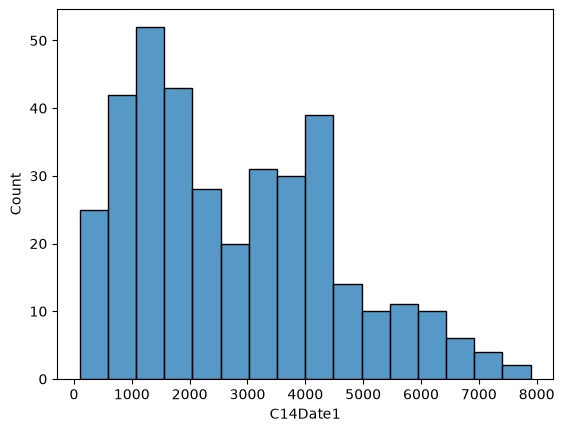

In [ ]:
sbn.histplot(data=radiocarbon, 
             x="C14Date1",
             binwidth = 500
             )
sbn.


In [18]:
#==============================================#
# CALIBRATE RADIOCARBON DATA
#==============================================#
# Calibrate radiocarbon samples to calendar years based on samples of known age.
# Calibration is conducted using IOSACAL package: https://c14.iosa.it/en/latest/.
# Marine and terrestrial data should be calibrated seperately.
# Assumes that dates not marked as from a marine source are terrestrial.

# Identify marine dates
# keywords: marine, shell, fat, whale, seal
marine_radiocarbon = radiocarbon[radiocarbon['C14SampTyp']
                .str.contains("marine|shell|fat|whale|seal", case=False)]

# Identify terrestrial dates
terrestrial_radiocarbon = radiocarbon[~ radiocarbon['C14SampTyp']
                .str.contains("marine|shell|fat|whale|seal", case=False)]

# record earliest and latest calibrated dates
# will be used for creating date mesh
cal_early = -float('inf')

# Calibrate terrestrial samples according to IntCal20 calibration curve
# Create combined date object for calibration
terrestrial_cals = []
for row in terrestrial_radiocarbon.itertuples(index=True):
    uncal = R(row.C14Date1, row.C14Vari1, row.C14LabNo1) 
    cal = uncal.calibrate("intcal20").tolist()
    terrestrial_cals.append(cal)
    early_cand = np.max(cal[0])
    if early_cand > cal_early:
        cal_early = early_cand
    

# Calibrate marine samples according to Marine20 calibration curve
marine_cals = []
for row in marine_radiocarbon.itertuples(index=True):
    uncal = R(row.C14Date1, row.C14Vari1, row.C14LabNo1) 
    cal = uncal.calibrate("marine20").tolist()
    marine_cals.append(cal)
    early_cand = np.max(cal[0])

    if early_cand > cal_early:
        cal_early = early_cand

In [19]:
print(int(cal_early))
# First create the grid of zeros. 
# Iteratet the grid and add date to relevant position.
# Sparse matrix: Optimization might be required. 

calibrations = terrestrial_cals + marine_cals

calibrated_density_grid = np.zeros((radiocarbon.shape[0], int(cal_early)+1))

for index, date_list in enumerate(calibrations):
   for density_estimate in date_list:
       calibrated_density_grid[index, int(density_estimate[0])] = density_estimate[1]



10756


In [20]:
# Trim calendar years and grid
calibrated_density_grid = calibrated_density_grid[:,500:8000]

# Define calendar years
calendar_years = np.arange(start=0,stop=calibrated_density_grid.shape[1])

## Display Posterior Density Plot vs Observed

In [69]:
# POSTERIOR CHECK: MIXTURE DENSITIES

spd = np.sum(calibrated_density_grid,axis=0)


idata = az.from_netcdf(f"gmm_k{3}.nc")

density_samples = idata.posterior["mixture_density"].values

In [55]:
posterior_density_curves = density_samples.reshape(4000,7500)
posterior_density_mean = np.mean(posterior_density_curves,axis=0)
#Credible interval computation
posterior_density_q1 = np.quantile(posterior_density_curves,q=0.975,axis=0)
posterior_density_q2 = np.quantile(posterior_density_curves,q=0.025,axis=0)



(400.0, 7500.0)

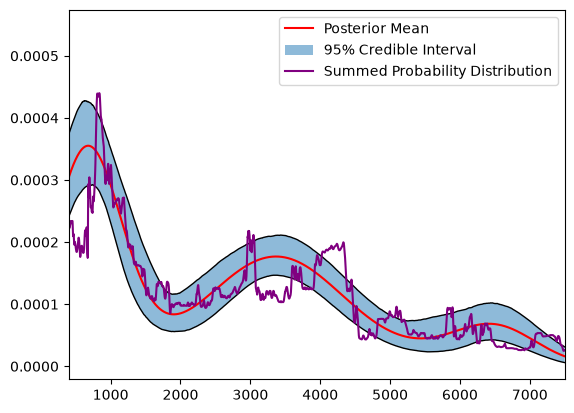

In [68]:

plt.plot(calendar_years, posterior_density_mean, color="red", label="Posterior Mean")
plt.plot(calendar_years, posterior_density_q1, color="black", linewidth=1)
plt.plot(calendar_years, posterior_density_q2,color="black" , linewidth=1)
plt.fill_between(calendar_years, posterior_density_q1,posterior_density_q2, alpha=0.5, label="95% Credible Interval")
plt.plot(calendar_years,spd/calibrated_density_grid.shape[0], color="purple", label="Summed Probability Distribution")
plt.legend()
plt.xlim(400,7500)


## Test Plot for k=1

(400.0, 7500.0)

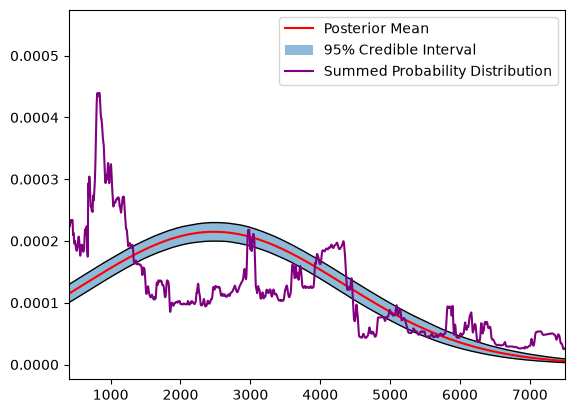

In [70]:
spd = np.sum(calibrated_density_grid,axis=0)

idata = az.from_netcdf(f"gmm_k{1}.nc")

density_samples = idata.posterior["mixture_density"].values

posterior_density_curves = density_samples.reshape(4000,7500)
posterior_density_mean = np.mean(posterior_density_curves,axis=0)
#Credible interval computation
posterior_density_q1 = np.quantile(posterior_density_curves,q=0.975,axis=0)
posterior_density_q2 = np.quantile(posterior_density_curves,q=0.025,axis=0)


plt.plot(calendar_years, posterior_density_mean, color="red", label="Posterior Mean")
plt.plot(calendar_years, posterior_density_q1, color="black", linewidth=1)
plt.plot(calendar_years, posterior_density_q2,color="black" , linewidth=1)
plt.fill_between(calendar_years, posterior_density_q1,posterior_density_q2, alpha=0.5, label="95% Credible Interval")
plt.plot(calendar_years,spd/calibrated_density_grid.shape[0], color="purple", label="Summed Probability Distribution")
plt.legend()
plt.xlim(400,7500)


# Test Plot For K = 2

(400.0, 7500.0)

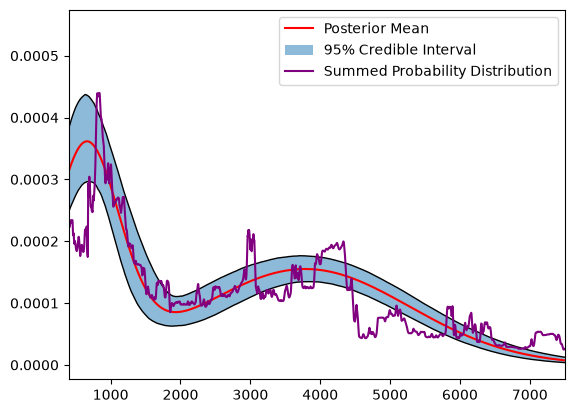

In [71]:
spd = np.sum(calibrated_density_grid,axis=0)

idata = az.from_netcdf(f"gmm_k{2}.nc")

density_samples = idata.posterior["mixture_density"].values

posterior_density_curves = density_samples.reshape(4000,7500)
posterior_density_mean = np.mean(posterior_density_curves,axis=0)
#Credible interval computation
posterior_density_q1 = np.quantile(posterior_density_curves,q=0.975,axis=0)
posterior_density_q2 = np.quantile(posterior_density_curves,q=0.025,axis=0)


plt.plot(calendar_years, posterior_density_mean, color="red", label="Posterior Mean")
plt.plot(calendar_years, posterior_density_q1, color="black", linewidth=1)
plt.plot(calendar_years, posterior_density_q2,color="black" , linewidth=1)
plt.fill_between(calendar_years, posterior_density_q1,posterior_density_q2, alpha=0.5, label="95% Credible Interval")
plt.plot(calendar_years,spd/calibrated_density_grid.shape[0], color="purple", label="Summed Probability Distribution")
plt.legend()
plt.xlim(400,7500)


# Test Plot for K=4


(400.0, 7500.0)

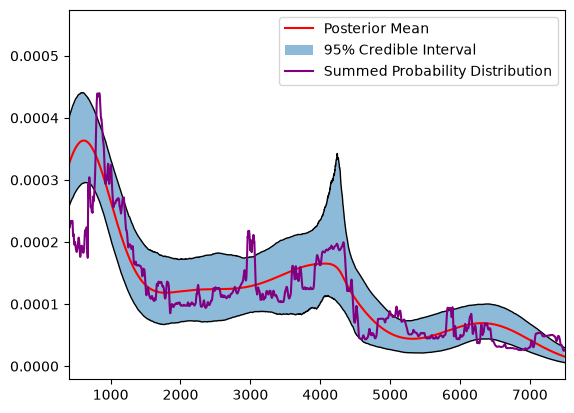

In [72]:

spd = np.sum(calibrated_density_grid,axis=0)

idata = az.from_netcdf(f"gmm_k{4}.nc")

density_samples = idata.posterior["mixture_density"].values

posterior_density_curves = density_samples.reshape(4000,7500)
posterior_density_mean = np.mean(posterior_density_curves,axis=0)
#Credible interval computation
posterior_density_q1 = np.quantile(posterior_density_curves,q=0.975,axis=0)
posterior_density_q2 = np.quantile(posterior_density_curves,q=0.025,axis=0)


plt.plot(calendar_years, posterior_density_mean, color="red", label="Posterior Mean")
plt.plot(calendar_years, posterior_density_q1, color="black", linewidth=1)
plt.plot(calendar_years, posterior_density_q2,color="black" , linewidth=1)
plt.fill_between(calendar_years, posterior_density_q1,posterior_density_q2, alpha=0.5, label="95% Credible Interval")
plt.plot(calendar_years,spd/calibrated_density_grid.shape[0], color="purple", label="Summed Probability Distribution")
plt.legend()
plt.xlim(400,7500)

## Display Posterior Predictions and Summary Statistics
